# Technical validation: In-Ear EEG

In [1]:
import sys
from pathlib import Path
import os

sys.dont_write_bytecode = True
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / 'helpers/project_config.py').is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from helpers.project_config import load_project_config
from helpers.Eyeball import blink

CONFIG = load_project_config(PROJECT_ROOT / 'ImBrAid/config.json')
RAW_DATA_ROOT = CONFIG.path('paths', 'publication_raw_data_root')


In [2]:
quality_numbers = []
number_of_files = 0
for pid in os.listdir(RAW_DATA_ROOT):
    pid_path = RAW_DATA_ROOT / pid
    idun_path = pid_path / 'IDUN'
    if not pid_path.is_dir() or not idun_path.is_dir() or not any(idun_path.glob('*_quality.csv')):
        continue
    quality_csv = next(idun_path.glob('*_quality.csv'))
    quality_df = pd.read_csv(quality_csv, header=0, index_col=0)
    quality_numbers.extend(quality_df['signalQuality'].values)
    number_of_files += 1
    
quality_numbers = np.array(quality_numbers)
number_of_files

26

In [3]:
len(quality_numbers), np.mean(quality_numbers), np.std(quality_numbers), np.min(quality_numbers), np.max(quality_numbers)

(14461, 75.85138590540251, 13.577994258995849, 0.0, 99.94501069125258)

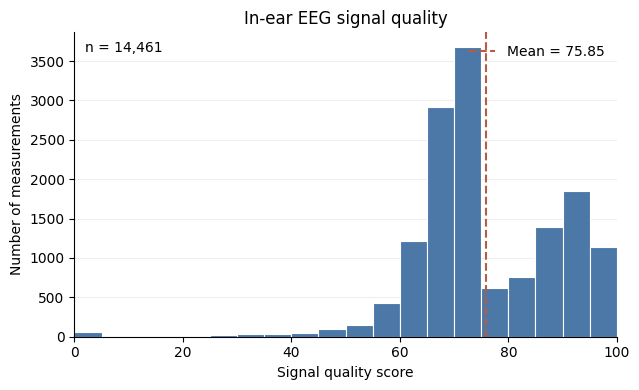

In [4]:
quality_values = np.asarray(quality_numbers, dtype=float)
quality_values = quality_values[np.isfinite(quality_values)]
if quality_values.size == 0:
    raise ValueError('No finite signal quality values are available.')

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(
    quality_values, bins=np.arange(0, 101, 5),
    color='#4C78A8', edgecolor='white', linewidth=0.8,
)
ax.axvline(
    quality_values.mean(), color='#B65B45', linestyle='--', linewidth=1.5,
    label=f'Mean = {quality_values.mean():.2f}',
)
ax.set(
    xlim=(0, 100), xlabel='Signal quality score',
    ylabel='Number of measurements', title='In-ear EEG signal quality',
)
ax.text(
    0.02, 0.97, f'n = {quality_values.size:,}',
    transform=ax.transAxes, ha='left', va='top',
)
ax.legend(frameon=False, loc='upper right')
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()


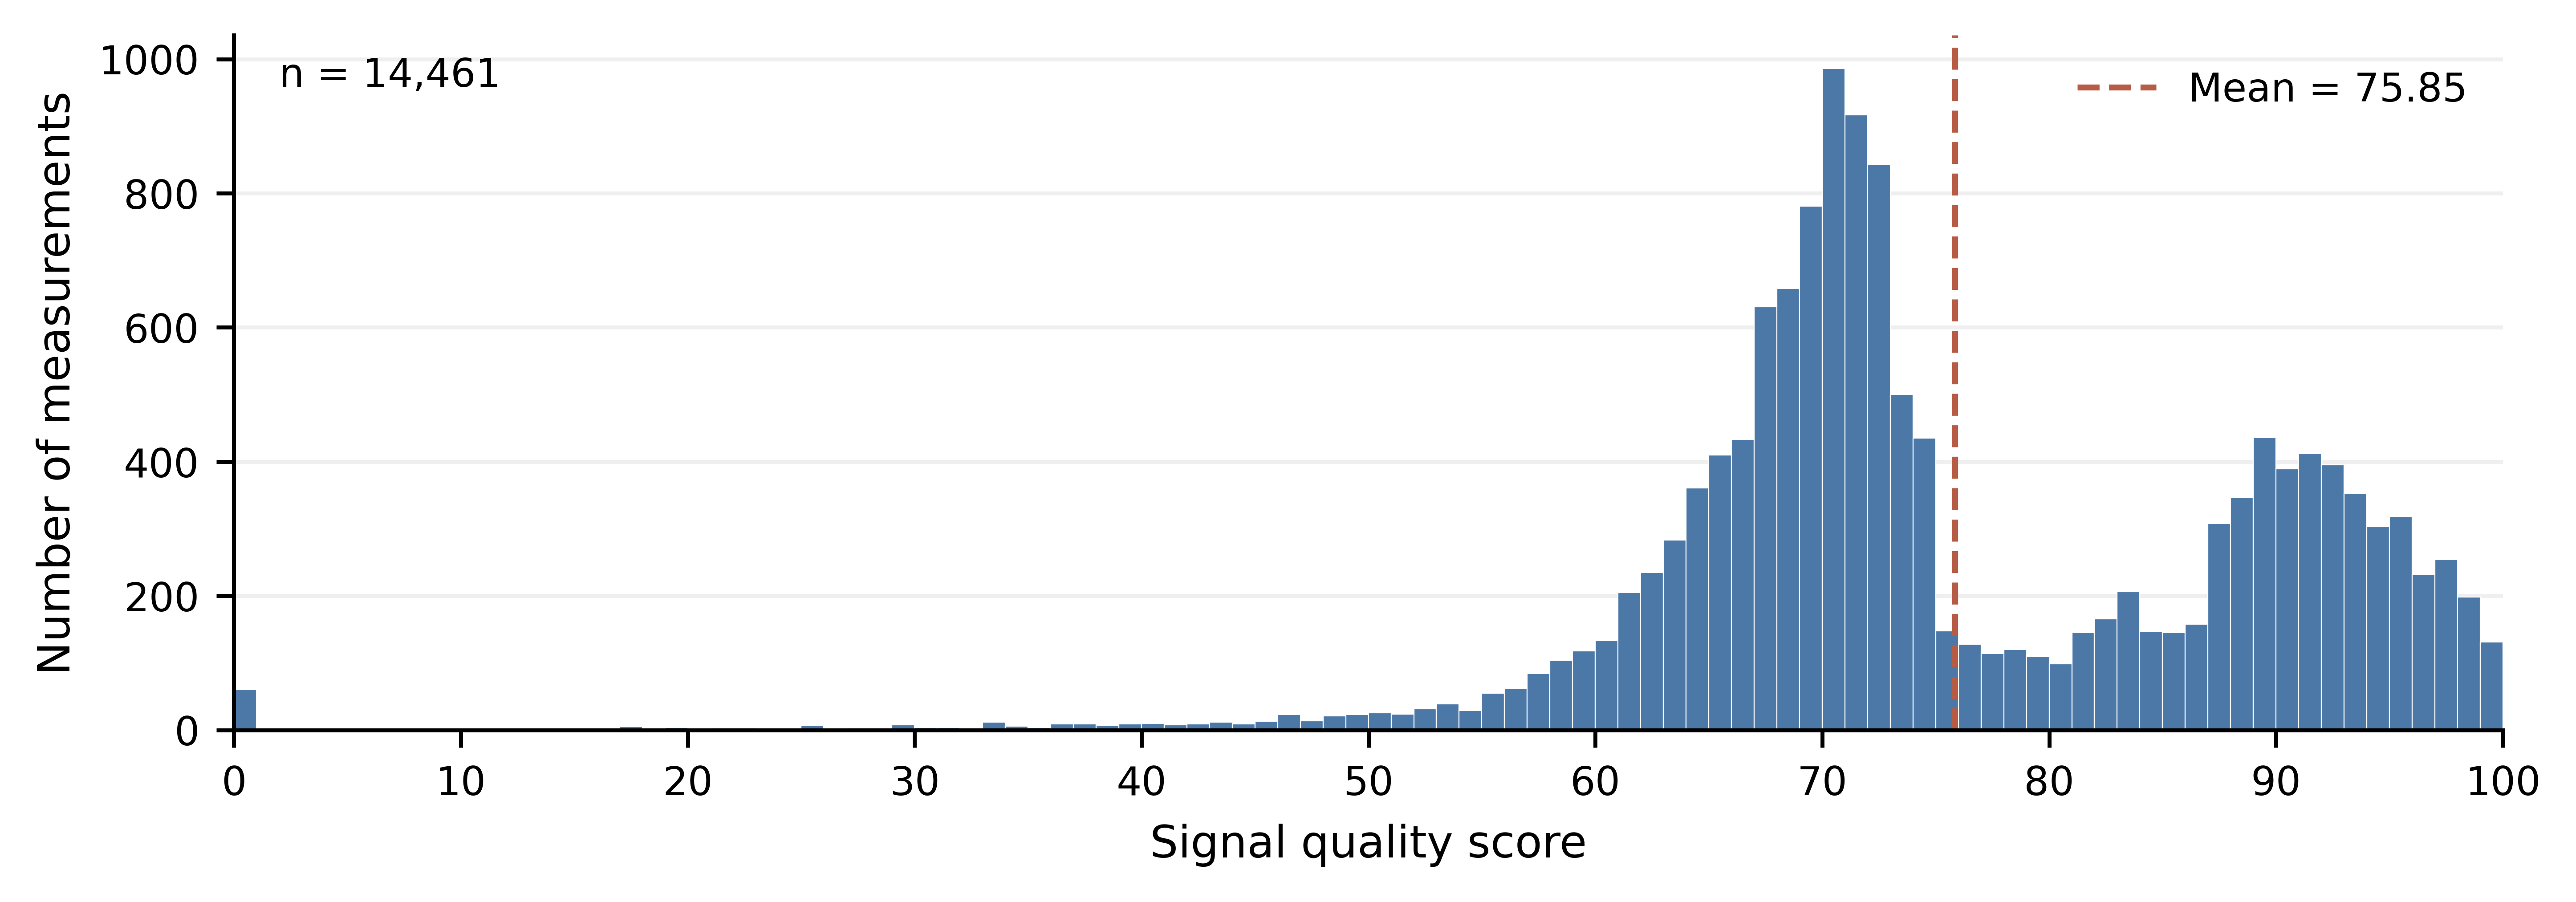

In [5]:
fig_wide, ax_wide = plt.subplots(figsize=(7.2, 2.5), dpi=800)
ax_wide.hist(
    quality_values, bins=np.arange(0, 101, 1),
    color='#4C78A8', edgecolor='white', linewidth=0.2,
)
ax_wide.axvline(
    quality_values.mean(), color='#B65B45', linestyle='--', linewidth=1.2,
    label=f'Mean = {quality_values.mean():.2f}',
)
ax_wide.set_xlim(0, 100)
ax_wide.set_xticks(np.arange(0, 101, 10))
ax_wide.set_xlabel('Signal quality score', fontsize=9)
ax_wide.set_ylabel('Number of measurements', fontsize=9)
# ax_wide.set_title('In-ear EEG signal quality', fontsize=10)
ax_wide.tick_params(labelsize=8)
ax_wide.text(
    0.02, 0.97, f'n = {quality_values.size:,}',
    transform=ax_wide.transAxes, ha='left', va='top', fontsize=8,
)
ax_wide.legend(frameon=False, loc='upper right', fontsize=8)
ax_wide.set_axisbelow(True)
ax_wide.grid(axis='y', alpha=0.2)
ax_wide.spines[['top', 'right']].set_visible(False)
fig_wide.tight_layout(pad=0.6)
plt.show()
